<a href="https://colab.research.google.com/github/aimlnielitropar/BTech-DL/blob/main/practical9_lstm_stock.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📈 Practical 9: Time Series Prediction with RNN vs LSTM
## Deep Learning Lab | BTech Semester 4

---

### 🎯 Objective
Solve the Vanishing Gradient problem in plain RNNs using **Long Short-Term Memory (LSTM)** networks. Predict future stock prices and compare Simple RNN vs LSTM using Mean Squared Error.

### 📌 What You Will Learn
- How RNNs process sequential data using hidden states
- Why plain RNNs suffer from the Vanishing Gradient problem on long sequences
- How LSTM gates (Input, Forget, Output) solve long-term dependency learning
- The Windowing method for time series dataset creation
- Comparing RNN vs LSTM on stock price prediction

### 📚 References
- Hochreiter & Schmidhuber (1997) — *Long Short-Term Memory*
  https://www.bioinf.jku.at/publications/older/2604.pdf
- Bengio et al. (1994) — *Learning Long-Term Dependencies with Gradient Descent is Difficult*
- Keras RNN Guide: https://www.tensorflow.org/guide/keras/rnn
- Google Stock Price Dataset: https://www.kaggle.com/datasets/

---

## 📦 Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow: {tf.__version__}')

TensorFlow: 2.20.0


## 🧠 Step 2: Theory — RNN and Vanishing Gradient Problem

A plain RNN processes sequences step by step:
$$h_t = \tanh(W_h h_{t-1} + W_x x_t + b)$$

**Vanishing Gradient Problem:**
During BPTT (Backpropagation Through Time), gradients are multiplied by $W_h$ at each time step.
If $|W_h| < 1$, gradients shrink exponentially → early time steps get nearly zero gradient → no learning!

**LSTM Solution:** Uses gating mechanisms to control what to remember and what to forget.

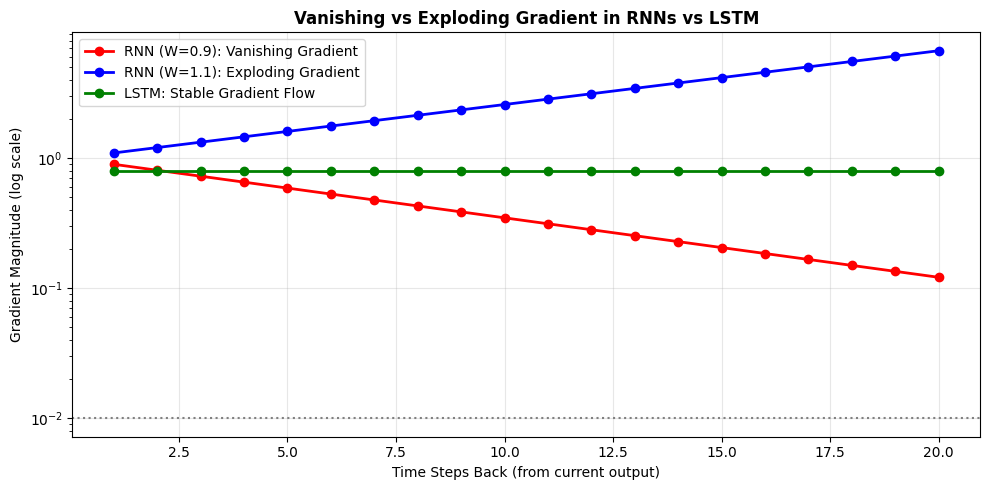

In a 20-step sequence, vanishing RNN gradient is reduced to: 0.121577
The early steps of the sequence get nearly ZERO gradient → no learning!


In [2]:
# plotting how gradients behave across time steps for RNN vs LSTM
timesteps = np.arange(1, 21)
gradient_rnn_small = 0.9 ** timesteps   # W < 1: vanishes
gradient_rnn_large = 1.1 ** timesteps   # W > 1: explodes
gradient_lstm      = np.ones(20) * 0.8  # LSTM: relatively stable

plt.figure(figsize=(10, 5))
plt.plot(timesteps, gradient_rnn_small, 'r-o', label='RNN (W=0.9): Vanishing Gradient', linewidth=2)
plt.plot(timesteps, gradient_rnn_large, 'b-o', label='RNN (W=1.1): Exploding Gradient', linewidth=2)
plt.plot(timesteps, gradient_lstm,      'g-o', label='LSTM: Stable Gradient Flow',       linewidth=2)
plt.yscale('log')
plt.xlabel('Time Steps Back (from current output)')
plt.ylabel('Gradient Magnitude (log scale)')
plt.title('Vanishing vs Exploding Gradient in RNNs vs LSTM', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0.01, color='gray', linestyle=':', label='Effective zero threshold')
plt.tight_layout()
plt.show()

print('in a 20-step sequence, the vanishing RNN gradient becomes:', round(0.9**20, 6))
print('early time steps get nearly zero gradient — the network basically ignores them and never learns from them!')

## 🔑 Step 3: LSTM Gate Diagram

LSTM introduces three gates and a cell state $C_t$ (long-term memory):

| Gate | Formula | Purpose |
|------|---------|--------|
| **Forget Gate** | $f_t = \sigma(W_f [h_{t-1}, x_t] + b_f)$ | Decides what to erase from cell state |
| **Input Gate** | $i_t = \sigma(W_i [h_{t-1}, x_t] + b_i)$ | Decides what new info to write |
| **Output Gate** | $o_t = \sigma(W_o [h_{t-1}, x_t] + b_o)$ | Controls what to expose as hidden state |
| **Cell Update** | $C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$ | Update long-term memory |

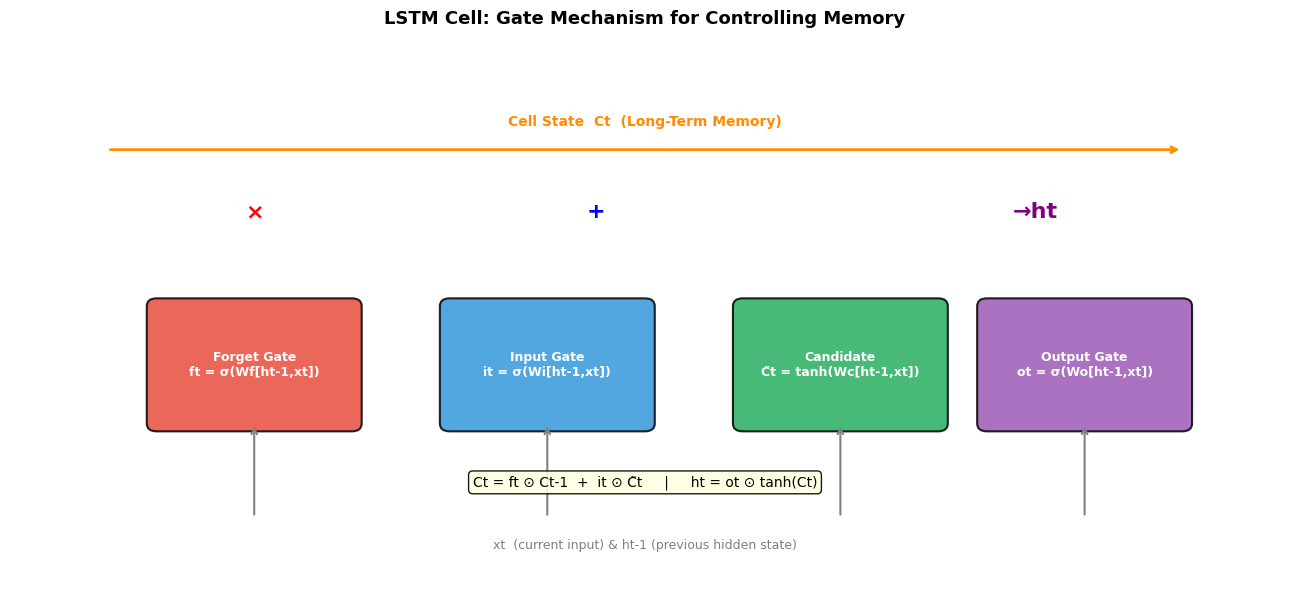

In [3]:
# Visualize LSTM cell diagram using matplotlib
fig, ax = plt.subplots(figsize=(13, 6))
ax.set_xlim(0, 13); ax.set_ylim(0, 7); ax.axis('off')

def draw_box(ax, x, y, w, h, label, color, fontsize=9):
    rect = mpatches.FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.1',
                                    facecolor=color, alpha=0.85, edgecolor='black', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x+w/2, y+h/2, label, ha='center', va='center',
            fontsize=fontsize, fontweight='bold', color='white')

# Cell state (top horizontal line)
ax.annotate('', xy=(12, 5.5), xytext=(1, 5.5), arrowprops=dict(arrowstyle='->', lw=2, color='darkorange'))
ax.text(6.5, 5.8, 'Cell State  Ct  (Long-Term Memory)', ha='center', fontsize=10, color='darkorange', fontweight='bold')

# Gate boxes
draw_box(ax, 1.5, 2, 2, 1.5, 'Forget Gate\nft = σ(Wf[ht-1,xt])', '#E74C3C')
draw_box(ax, 4.5, 2, 2, 1.5, 'Input Gate\nit = σ(Wi[ht-1,xt])', '#3498DB')
draw_box(ax, 7.5, 2, 2, 1.5, 'Candidate\nC̃t = tanh(Wc[ht-1,xt])', '#27AE60')
draw_box(ax, 10,  2, 2, 1.5, 'Output Gate\not = σ(Wo[ht-1,xt])', '#9B59B6')

# Inputs
for x_pos, label in [(2.5, 'xt (input)'), (5.5, 'xt (input)'), (8.5, 'xt (input)'), (11, 'xt (input)')]:
    ax.annotate('', xy=(x_pos, 2), xytext=(x_pos, 0.8), arrowprops=dict(arrowstyle='->', lw=1.5, color='gray'))
ax.text(6.5, 0.4, 'xt  (current input) & ht-1 (previous hidden state)', ha='center', fontsize=9, color='gray')

# Multiply/add connections to cell state
for x_pos, symbol, color in [(2.5, '×', 'red'), (6.0, '+', 'blue'), (10.5, '→ht', 'purple')]:
    ax.text(x_pos, 4.7, symbol, ha='center', va='center', fontsize=16, fontweight='bold', color=color)

ax.text(6.5, 1.2, 'Ct = ft ⊙ Ct-1  +  it ⊙ C̃t     |     ht = ot ⊙ tanh(Ct)',
        ha='center', fontsize=10, color='black',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

plt.title('LSTM Cell: Gate Mechanism for Controlling Memory', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 📊 Step 4: Generate/Load Stock Price Data

We generate a synthetic stock price series that mimics real stock behavior (trend + seasonality + noise). You can replace this with the real Google Stock CSV from Kaggle.

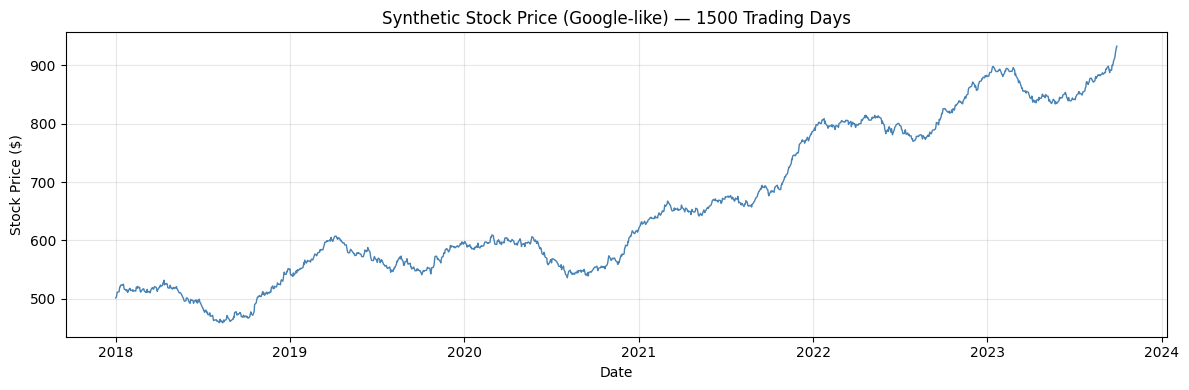

Total data points: 1500
Price range: $458.64 — $932.83


In [4]:
# ====================================================
# OPTION A: real Google stock price data from Kaggle
# uncomment if you have your Kaggle API key
# ====================================================
# !kaggle datasets download -d shreenidhihipparagi/google-stock-prediction
# df_stock = pd.read_csv('Google_Stock_Price_Train.csv')
# prices = df_stock['Open'].str.replace(',', '').astype(float).values

# ====================================================
# OPTION B: generating synthetic stock-like price data
# this looks realistic and runs without any downloads
# ====================================================
np.random.seed(42)
n_days = 1500
t = np.arange(n_days)

# combining three components: a rising trend + yearly pattern + random noise (like real stocks)
trend       = 500 + 0.15 * t  # slowly rising trend over time
seasonality = 40 * np.sin(2 * np.pi * t / 252)   # annual cycle — 252 trading days in a year
noise       = np.cumsum(np.random.randn(n_days) * 3)  # random walk (Brownian motion) to mimic stock randomness
prices      = trend + seasonality + noise
prices      = np.maximum(prices, 50)  # making sure prices don't go negative

# creating a proper date index (business days only)
dates = pd.date_range(start='2018-01-01', periods=n_days, freq='B')
df_stock = pd.DataFrame({'Date': dates, 'Open': prices})
df_stock.set_index('Date', inplace=True)

plt.figure(figsize=(12, 4))
plt.plot(df_stock.index, df_stock['Open'], color='steelblue', linewidth=1)
plt.title('Synthetic Stock Price (Google-like) — 1500 Trading Days', fontsize=12)
plt.xlabel('Date'); plt.ylabel('Stock Price ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Total data points: {len(prices)}')
print(f'Price range: ${prices.min():.2f} — ${prices.max():.2f}')

## 🪟 Step 5: The Windowing Method

To train an RNN/LSTM for time series prediction, we use the **sliding window** approach:
- Use the past `window_size` days as input features
- Predict the next day's price as the target

Example (window=3): `[Day1, Day2, Day3] → Day4`

Window size: 60 days
Total sequences: 1440
X shape: (1440, 60, 1)  (samples, timesteps, features)
y shape: (1440, 1)

Train sequences: 1152
Test sequences:  288


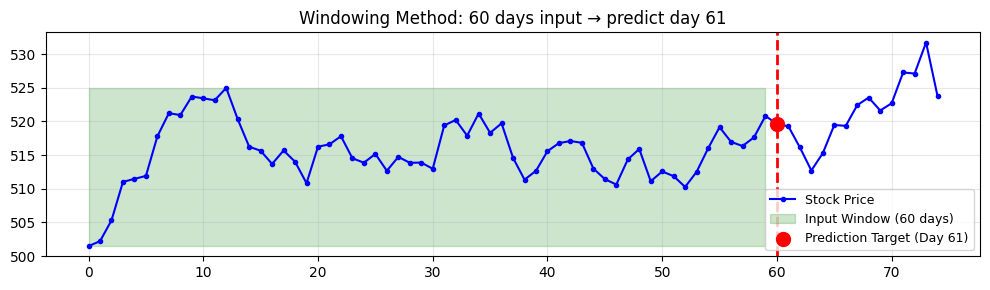

In [5]:
# normalizing prices to [0,1] range — RNN/LSTM are very sensitive to input scale
scaler = MinMaxScaler(feature_range=(0, 1))
prices_scaled = scaler.fit_transform(prices.reshape(-1, 1))  # Shape: (1500, 1)


def create_windows(data, window_size=60):
    """
    creates sliding window sequences for time series

    for each position t:
      X[t] = the past window_size days of prices
      y[t] = the next day's price (what we want to predict)

    Args:
        data: normalized price array
        window_size: how many past days to look at
    Returns:
        X: shape (N, window_size, 1)
        y: shape (N,)
    """
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i : i + window_size])       # this is our input: past 60 days
        y.append(data[i + window_size])            # this is what we want to predict: day 61
    return np.array(X), np.array(y)


WINDOW_SIZE = 60  # using the past 60 trading days (~3 months) to predict the next day

X_all, y_all = create_windows(prices_scaled, WINDOW_SIZE)
print(f'Window size: {WINDOW_SIZE} days')
print(f'Total sequences: {len(X_all)}')
print(f'X shape: {X_all.shape}  (samples, timesteps, features)')
print(f'y shape: {y_all.shape}')

# splitting 80/20 for train/test — NEVER shuffle time series data (future can't be in training set)
split = int(len(X_all) * 0.8)
X_train, X_test = X_all[:split], X_all[split:]
y_train, y_test = y_all[:split], y_all[split:]

print(f'\nTrain sequences: {len(X_train)}')
print(f'Test sequences:  {len(X_test)}')

# Visualize windowing concept
fig, ax = plt.subplots(figsize=(10, 3))
sample_data = prices[:75]
ax.plot(range(75), sample_data, 'b-o', markersize=3, label='Stock Price')
ax.fill_between(range(60), sample_data.min(), sample_data[:60].max(),
                alpha=0.2, color='green', label=f'Input Window (60 days)')
ax.axvline(60, color='red', linewidth=2, linestyle='--')
ax.scatter([60], [sample_data[60]], color='red', s=100, zorder=5, label='Prediction Target (Day 61)')
ax.set_title('Windowing Method: 60 days input → predict day 61')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 🏗️ Step 6: Build Simple RNN and LSTM Models

In [6]:
def build_simple_rnn(input_shape):
    """
    Simple RNN (Recurrent Neural Network).

    At each time step t:
        h_t = tanh(W_h * h_{t-1} + W_x * x_t + b)

    Limitation: Gradient vanishes over long sequences (>10-20 steps).
    With window=60, gradients from early steps are near-zero.
    """
    model = keras.Sequential([
        # return_sequences=True: pass the hidden state at every timestep to the next RNN layer
        layers.SimpleRNN(64, activation='tanh', return_sequences=True,
                         input_shape=input_shape, name='rnn1'),
        layers.Dropout(0.2),
        # return_sequences=False: only pass the final timestep output to the Dense layer
        layers.SimpleRNN(32, activation='tanh', return_sequences=False, name='rnn2'),
        layers.Dropout(0.2),
        layers.Dense(1, name='output')  # output: single number (next day's price) — no activation since it's regression
    ], name='SimpleRNN')

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model


def build_lstm(input_shape):
    """
    LSTM (Long Short-Term Memory) network.

    LSTM uses 3 gates to solve the vanishing gradient problem:
    - Forget gate: decides what to erase from memory
    - Input gate: decides what new information to store
    - Output gate: decides what to output from memory

    The cell state (C_t) acts as a 'conveyor belt' that carries
    information across many time steps unchanged.
    """
    model = keras.Sequential([
        layers.LSTM(64, return_sequences=True, input_shape=input_shape, name='lstm1'),
        layers.Dropout(0.2),
        layers.LSTM(32, return_sequences=False, name='lstm2'),
        layers.Dropout(0.2),
        layers.Dense(1, name='output')
    ], name='LSTM')

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model


INPUT_SHAPE = (WINDOW_SIZE, 1)

rnn_model  = build_simple_rnn(INPUT_SHAPE)
lstm_model = build_lstm(INPUT_SHAPE)

print('Simple RNN:')
rnn_model.summary()
print('\nLSTM:')
lstm_model.summary()

Simple RNN:


Model: "SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rnn1 (SimpleRNN)                │ (None, 60, 64)         │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn2 (SimpleRNN)                │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,361 (28.75 KB)

 Trainable params: 7,361 (28.75 KB)

...

Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm1 (LSTM)                    │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm2 (LSTM)                    │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

## 🚀 Step 7: Train Both Models

In [7]:
EPOCHS = 30
BATCH  = 32

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=7, restore_best_weights=True
)

# training the simple RNN first
print('Training Simple RNN...')
rnn_history = rnn_model.fit(
    X_train, y_train,
    epochs=EPOCHS, batch_size=BATCH,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)
print(f'RNN trained for {len(rnn_history.history["loss"])} epochs')

# now training the LSTM for comparison
print('\nTraining LSTM...')
lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=EPOCHS, batch_size=BATCH,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)
print(f'LSTM trained for {len(lstm_history.history["loss"])} epochs')

Training Simple RNN...
Epoch 1/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 0.0846 - mae: 0.2165 - val_loss: 0.0045 - val_mae: 0.0633
Epoch 2/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0261 - mae: 0.1208 - val_loss: 0.0036 - val_mae: 0.0564
Epoch 3/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0151 - mae: 0.0913 - val_loss: 0.0038 - val_mae: 0.0590
Epoch 4/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0106 - mae: 0.0770 - val_loss: 4.0078e-04 - val_mae: 0.0164
Epoch 5/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0082 - mae: 0.0669 - val_loss: 0.0013 - val_mae: 0.0323
Epoch 6/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.0074 - mae: 0.0622 - val_loss: 5.1366e-04 - val_mae: 0.0187
Epoch 7/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.0057 - mae: 0.0549 - val_loss: 7.9455e-04 - val_mae: 0.0242
Epoch 8/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0052 - mae: 0.0524 - val_loss: 2.2711e-04 - val_mae: 0.0118
Epoch 9/30
33/33 ━━━━━━━━

## 📊 Step 8: Compare Loss Curves

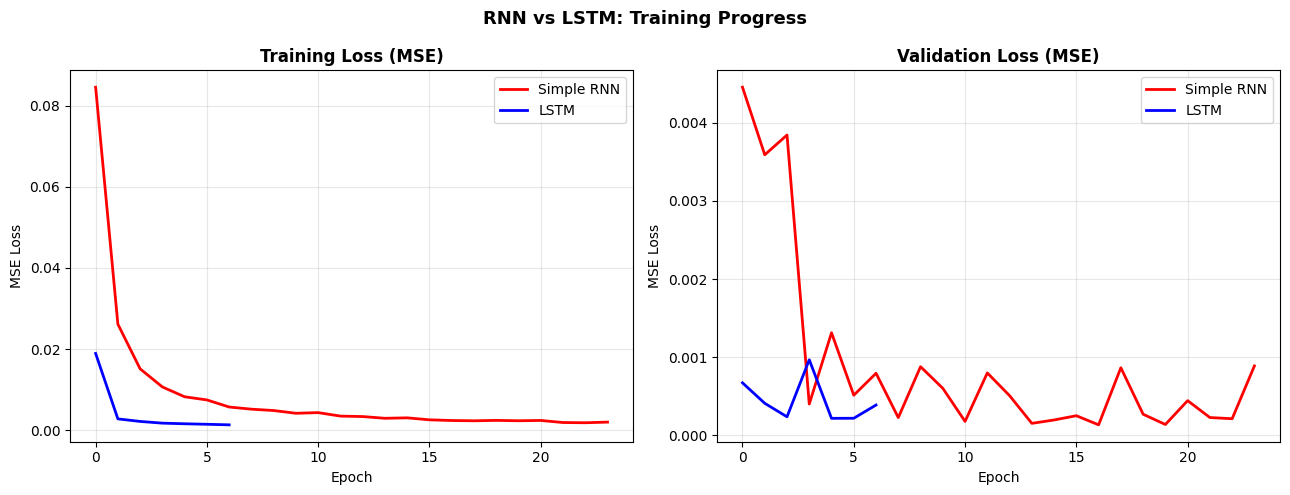

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric, title in zip(axes, ['loss', 'val_loss'], ['Training Loss (MSE)', 'Validation Loss (MSE)']):
    ax.plot(rnn_history.history[metric],  'r-', label='Simple RNN', linewidth=2)
    ax.plot(lstm_history.history[metric], 'b-', label='LSTM',       linewidth=2)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('RNN vs LSTM: Training Progress', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 🔮 Step 9: Predict and Visualize on Test Data

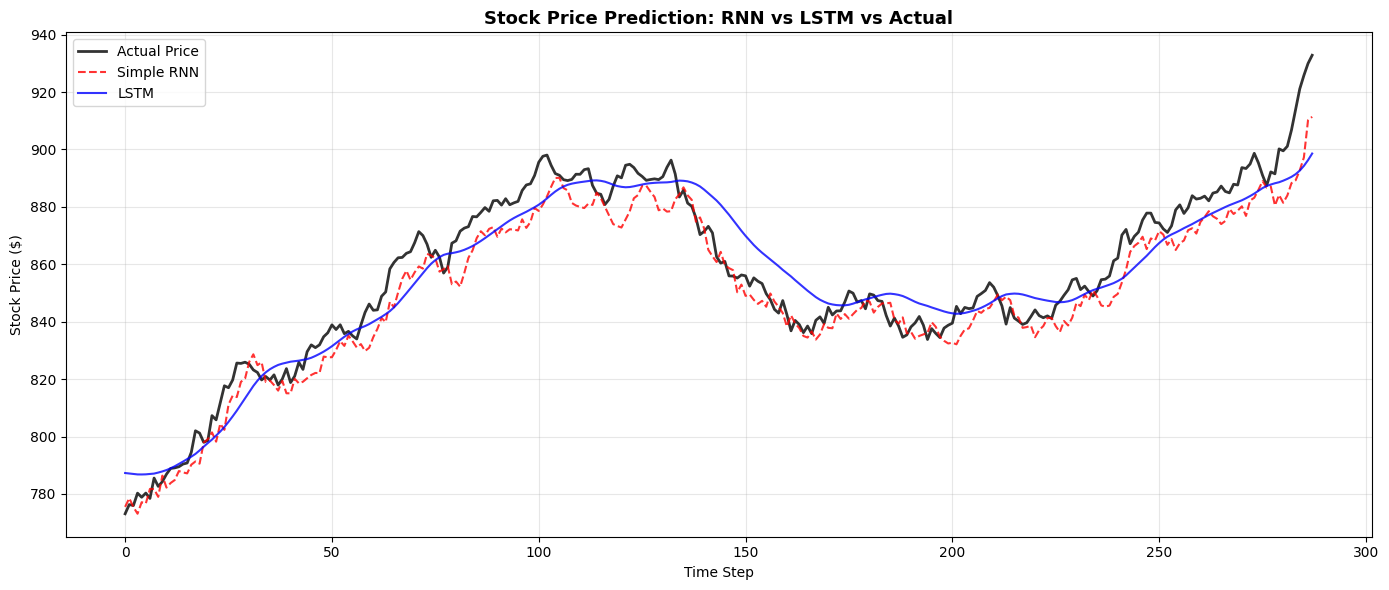

In [9]:
# running both models on the test set to get predictions
rnn_pred  = rnn_model.predict(X_test, verbose=0)
lstm_pred = lstm_model.predict(X_test, verbose=0)

# converting predictions back from [0,1] normalized scale to actual dollar prices
rnn_pred_actual  = scaler.inverse_transform(rnn_pred)
lstm_pred_actual = scaler.inverse_transform(lstm_pred)
y_test_actual    = scaler.inverse_transform(y_test.reshape(-1, 1))

# Plot predictions vs actual
plt.figure(figsize=(14, 6))
plt.plot(y_test_actual,    'k-',  linewidth=2, label='Actual Price',  alpha=0.8)
plt.plot(rnn_pred_actual,  'r--', linewidth=1.5, label='Simple RNN',  alpha=0.8)
plt.plot(lstm_pred_actual, 'b-',  linewidth=1.5, label='LSTM',        alpha=0.8)
plt.title('Stock Price Prediction: RNN vs LSTM vs Actual', fontsize=13, fontweight='bold')
plt.xlabel('Time Step')
plt.ylabel('Stock Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 📏 Step 10: Quantitative Comparison — MSE and MAE

  METRIC          |  Simple RNN   |    LSTM
  MSE             |     77.2568   |     89.9253
  RMSE ($)        |      8.7896   |      9.4829
  MAE ($)         |      7.0492   |      7.5757
  RNN is better by: 16.4% on this run
  (LSTM advantage is more pronounced on longer sequences)


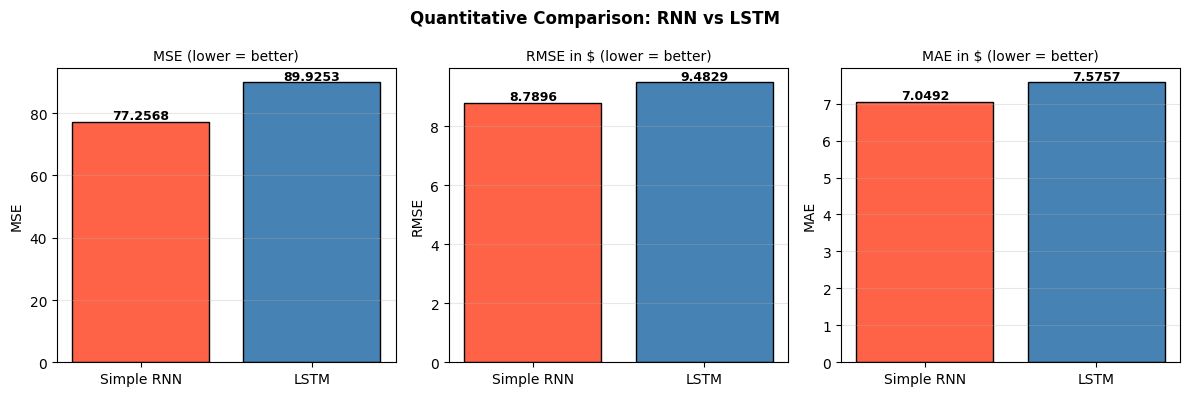

In [10]:
# computing MSE, RMSE, and MAE in actual dollar terms
rnn_mse  = mean_squared_error(y_test_actual, rnn_pred_actual)
lstm_mse = mean_squared_error(y_test_actual, lstm_pred_actual)
rnn_mae  = mean_absolute_error(y_test_actual, rnn_pred_actual)
lstm_mae = mean_absolute_error(y_test_actual, lstm_pred_actual)
rnn_rmse  = np.sqrt(rnn_mse)
lstm_rmse = np.sqrt(lstm_mse)

print('='*55)
print(f'  METRIC          |  Simple RNN   |    LSTM')
print('='*55)
print(f'  MSE             |  {rnn_mse:>10.4f}   |  {lstm_mse:>10.4f}')
print(f'  RMSE ($)        |  {rnn_rmse:>10.4f}   |  {lstm_rmse:>10.4f}')
print(f'  MAE ($)         |  {rnn_mae:>10.4f}   |  {lstm_mae:>10.4f}')
print('='*55)
improvement = (rnn_mse - lstm_mse) / rnn_mse * 100
if improvement > 0:
    print(f'  LSTM is better by: {improvement:.1f}% (lower MSE)')
else:
    print(f'  RNN is better by: {-improvement:.1f}% on this run')
    print('  (LSTM advantage is more pronounced on longer sequences)')

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
models = ['Simple RNN', 'LSTM']
for ax, (metric, vals, title) in zip(axes, [
    ('MSE',  [rnn_mse, lstm_mse],   'MSE (lower = better)'),
    ('RMSE', [rnn_rmse, lstm_rmse], 'RMSE in $ (lower = better)'),
    ('MAE',  [rnn_mae, lstm_mae],   'MAE in $ (lower = better)'),
]):
    colors = ['tomato', 'steelblue']
    bars = ax.bar(models, vals, color=colors, edgecolor='black')
    ax.set_title(title, fontsize=10)
    ax.set_ylabel(metric)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Quantitative Comparison: RNN vs LSTM', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 🔄 Step 11: Multi-Step Forecasting (Future Prediction)

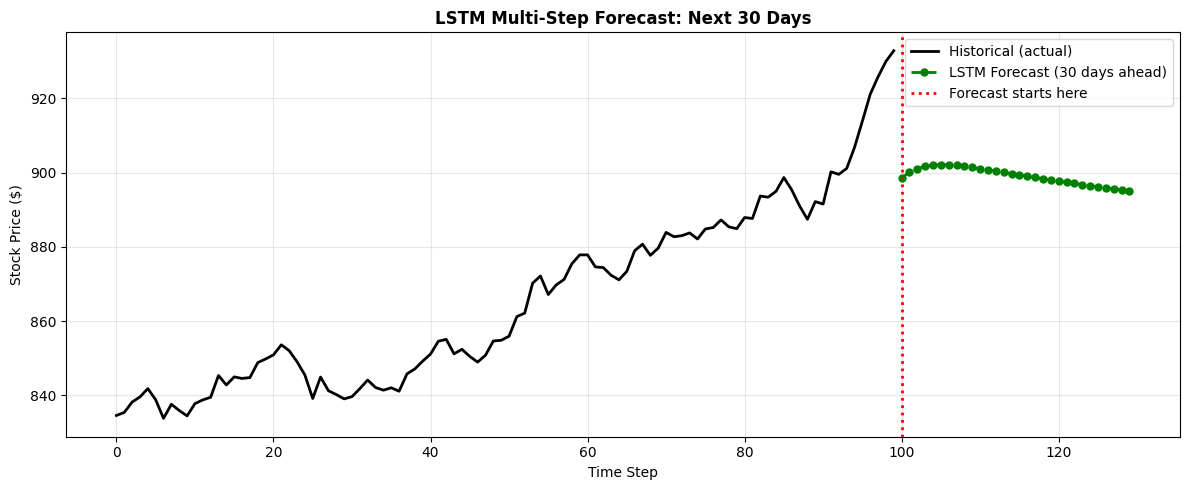

Note: Iterative forecasting accumulates errors over long horizons.
Real-world stock prediction is extremely difficult — this is for learning purposes only!


In [11]:
# predicting the next 30 days into the future using the LSTM
# we start from the last known 60 days and keep feeding our own predictions back in

n_future = 30
last_window = X_test[-1].copy()  # starting from the last 60 days of actual data
future_preds = []

for _ in range(n_future):
    # predicting the next day's price
    pred = lstm_model.predict(last_window.reshape(1, WINDOW_SIZE, 1), verbose=0)[0, 0]
    future_preds.append(pred)
    # shifting the window: drop the oldest day, add our latest prediction
    last_window = np.roll(last_window, -1, axis=0)
    last_window[-1, 0] = pred

# converting future predictions back to actual dollar scale
future_actual = scaler.inverse_transform(np.array(future_preds).reshape(-1, 1))

# Plot
plt.figure(figsize=(12, 5))
last_n = 100
plt.plot(range(last_n), y_test_actual[-last_n:], 'k-', linewidth=2, label='Historical (actual)')
plt.plot(range(last_n, last_n+n_future), future_actual, 'g--o',
         linewidth=2, markersize=5, label=f'LSTM Forecast ({n_future} days ahead)')
plt.axvline(last_n, color='red', linestyle=':', linewidth=2, label='Forecast starts here')
plt.title(f'LSTM Multi-Step Forecast: Next {n_future} Days', fontsize=12, fontweight='bold')
plt.xlabel('Time Step'); plt.ylabel('Stock Price ($)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print('note: feeding predictions back into the model accumulates errors — longer forecasts become less reliable')
print('real stock prices are almost impossible to predict accurately — this is just for learning LSTM concepts!')

---

## 📝 Summary

| Feature | Simple RNN | LSTM |
|---------|-----------|------|
| Memory mechanism | Hidden state only | Hidden state + Cell state |
| Long-term dependency | Poor (vanishing gradient) | Excellent (gates) |
| Gates | None | Forget, Input, Output |
| Parameters | Fewer | ~4× more than RNN |
| Training stability | Unstable for long seqs | Stable |
| Best use case | Short sequences (<10 steps) | Long sequences, time series |

---

## ❓ Viva / Self-Check Questions

1. **What is the Vanishing Gradient Problem in RNNs?** Why does it occur during Backpropagation Through Time (BPTT)?

2. **How does LSTM solve the Vanishing Gradient problem?** Explain the role of the cell state ($C_t$).

3. **Explain the three LSTM gates.** What does each gate control?

4. **What is the Windowing method?** How would you create windows of size 30 from a 200-step series? How many windows result?

5. **Why should we NOT shuffle the training data when splitting time series?** What would go wrong?

6. **What does `return_sequences=True` do in an LSTM layer?** When do you need it vs `return_sequences=False`?

7. **What is Truncated BPTT?** How does it reduce the computational cost of training RNNs?

8. **What is GRU (Gated Recurrent Unit)?** How does it differ from LSTM? What are its two gates?